# CICIDS2017 – Baseline Exploration

Bu notebook, CS401 kapsamındaki anomaly detection projesi için CICIDS2017 cleaned dataset'ini tanımaya ve temel veri keşfi adımlarını hazırlamaya odaklanır.

**Hedefler**
- Veri setinin boyutunu ve sütun yapısını gözlemlemek
- Eksik değer ve dağılım kontrollerine altyapı oluşturmak
- Sonraki modelleme notebook'ları için tekrar kullanılabilir yardımcı fonksiyonlar tanımlamak


## 1. Ortam Ayarları
Proje kök dizinini, veri yolunu ve pandas görüntüleme ayarlarını tek seferde yapılandıralım.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "data" / "cicids2017_cleaned.csv"


## 2. Veri Yükleme
CICIDS2017 cleaned CSV dosyasını okuyup hafızaya alıyoruz; gerekirse `ROW_LIMIT` ile kısaltılabilir.


In [2]:
ROW_LIMIT = 250_000  # tüm veriyi yüklemek için None

read_kwargs = {"low_memory": False}
if ROW_LIMIT is not None:
    read_kwargs["nrows"] = ROW_LIMIT

df = pd.read_csv(DATA_PATH, **read_kwargs)
print(f"Loaded {len(df):,} rows / {df.shape[1]} columns from {DATA_PATH.name}")


Loaded 250,000 rows / 53 columns from cicids2017_cleaned.csv


### 2.1 Hızlı Önizleme
İlk satırları ve genel bilgi çıktısını inceleyerek sütun tiplerini doğruluyoruz.


In [3]:
display(df.head())
df.info()


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,PSH Flag Count,ACK Flag Count,Average Packet Size,Subflow Fwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,158.045455,312.675250,7595.104640,67.122468,15075.50000,104051.399700,948537,0,1266342,31658.550,159355.2595,996324,2,317671,7387.697674,19636.44809,104616,1,1328,1424,32.376720,34.745748,0,976,111.837209,239.686848,57449.78495,0,1,0,113.152941,2664,29200,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,158.045455,312.675250,7289.936810,64.425518,15706.58333,104861.870100,955790,1,1319353,32983.825,159247.9008,996423,1,363429,8451.837209,21337.26261,104815,1,1328,1424,31.075838,33.349680,0,976,111.837209,239.686848,57449.78495,0,1,0,113.152941,2664,29200,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,12500.000000,160.00000,0.000000,160,160,0,0.000,0.0000,0,0,0,0.000000,0.00000,0,0,32,32,6250.000000,6250.000000,0,0,0.000000,0.000000,0.00000,0,0,1,0.000000,0,290,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,157.952381,319.121427,7182.267884,63.675308,15896.19512,106554.899000,956551,0,1303488,32587.200,160397.0499,997357,1,346851,8459.780488,23962.23892,138295,0,1328,1360,31.454068,32.221240,0,976,111.452381,241.642791,58391.23867,0,1,0,112.795181,2728,29200,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,38961.038960,38.50000,14.849242,49,28,0,0.000,0.0000,0,0,49,49.000000,0.00000,49,49,32,64,12987.012990,25974.025970,0,0,0.000000,0.000000,0.00000,0,0,1,0.000000,0,243,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 53 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             250000 non-null  int64  
 1   Flow Duration                250000 non-null  int64  
 2   Total Fwd Packets            250000 non-null  int64  
 3   Total Length of Fwd Packets  250000 non-null  int64  
 4   Fwd Packet Length Max        250000 non-null  int64  
 5   Fwd Packet Length Min        250000 non-null  int64  
 6   Fwd Packet Length Mean       250000 non-null  float64
 7   Fwd Packet Length Std        250000 non-null  float64
 8   Bwd Packet Length Max        250000 non-null  int64  
 9   Bwd Packet Length Min        250000 non-null  int64  
 10  Bwd Packet Length Mean       250000 non-null  float64
 11  Bwd Packet Length Std        250000 non-null  float64
 12  Flow Bytes/s                 250000 non-null  float64
 13 

### 2.2 Eksik Değer ve Etiket Dağılımı
Eksik kolon var mı kontrol ediyor ve Attack Type dağılımını yüzdesel olarak raporluyoruz.


In [3]:
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]

if not missing.empty:
    display(missing.to_frame(name="missing_ratio"))
else:
    print("Eksik değer bulunamadı.")

if "Attack Type" in df.columns:
    attack_dist = df["Attack Type"].value_counts(normalize=True).mul(100).round(2)
    display(attack_dist.to_frame(name="percent"))
else:
    print("Attack Type kolonu bulunamadı.")


Eksik değer bulunamadı.


,percent
Attack Type,
Normal Traffic,63.45
Port Scanning,36.28
Web Attacks,0.27


## 3. Binary Label Oluşturma
Attack Type bilgisini 0=normal / 1=attack şeklinde tek kolonla temsil ediyoruz.


In [4]:
df["label"] = df["Attack Type"].apply(lambda x: 0 if x == "Normal Traffic" else 1)

label_dist = df["label"].value_counts(normalize=True).mul(100).round(2)
display(label_dist.to_frame(name="percent"))


,percent
label,
0,63.45
1,36.55


## 4. Train/Test Ayrımı ve Özellik Seti
Model sadece normal trafiği görerek eğitilecek, test seti ise tüm veriyi içerecek.


In [5]:
# 1) Özellik listesi (Attack Type ve label hariç)
feature_cols = df.columns.drop(["Attack Type", "label"])

# 2) Eğitim verisi: sadece normal trafik
train_df = df[df["label"] == 0]

# 3) Test verisi: tüm trafik (normal + attack)
test_df = df.copy()

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_test = test_df["label"]

X_train.shape, X_test.shape


((158619, 52), (250000, 52))

## 5. Isolation Forest Eğitimi
Normal trafikten türettiğimiz özelliklerle unsupervised modeli kuruyoruz.


In [6]:
from sklearn.ensemble import IsolationForest

# X_train veri seti büyük gelirse örnekleme yapabilirsin:
# X_train_sample = X_train.sample(50_000, random_state=42)
# Şimdilik tamamını kullanalım.
X_train_fit = X_train.to_numpy()

iso = IsolationForest(
    n_estimators=200,
    contamination=0.36,  # yaklaşık saldırı oranı
    random_state=42,
    n_jobs=-1,
)
iso.fit(X_train_fit)


,n_estimators,200
,max_samples,'auto'
,contamination,0.36
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


## 6. Tahmin
Model çıktısını beklediğimiz etiket formatına (0=normal, 1=attack) dönüştürüyoruz.


In [7]:
# IsolationForest çıktısı: 1 = normal, -1 = anomaly
raw_pred = iso.predict(X_test.to_numpy())

y_pred = np.where(raw_pred == 1, 0, 1)
y_pred[:10]


array([1, 1, 0, 1, 0, 0, 1, 0, 0, 0])

## 7. Değerlendirme
Confusion matrix ve sınıflandırma raporu ile performansı ölçüyoruz.


In [8]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))


[[101516  57103]
 [ 41342  50039]]
              precision    recall  f1-score   support

           0      0.711     0.640     0.673    158619
           1      0.467     0.548     0.504     91381

    accuracy                          0.606    250000
   macro avg      0.589     0.594     0.589    250000
weighted avg      0.622     0.606     0.612    250000



### 7.1 Confusion Matrix Heatmap
Metin çıktısına ek olarak, aynı matrisi görselleştirip yanlış pozitif/negatif dağılımını hızlıca okuyalım.


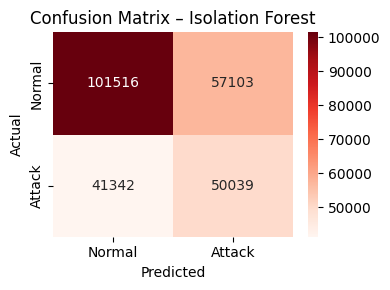

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix – Isolation Forest")
plt.tight_layout()
plt.show()


### 7.2 Özellik Dağılımı Karşılaştırmaları
Flow Duration ve Flow Bytes/s özelliklerinin normal ve saldırı örneklerindeki davranışını log-ölçekli histogramlarla kıyaslayalım.


C:\Users\emirh\AppData\Local\Temp\ipykernel_22580\278971545.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Label", loc="upper right")
C:\Users\emirh\AppData\Local\Temp\ipykernel_22580\278971545.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Label", loc="upper right")


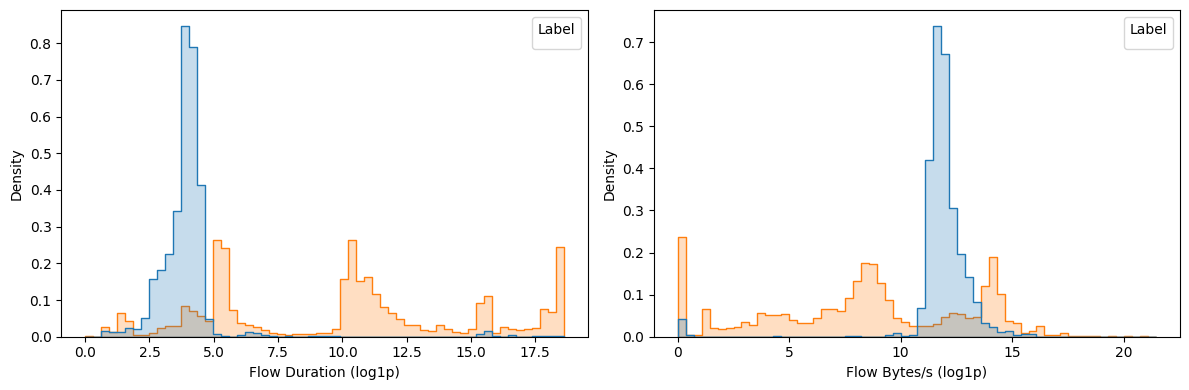

In [10]:
sample_n = min(50_000, len(df))
plot_df = df.sample(sample_n, random_state=42).copy()
plot_df["label_name"] = plot_df["label"].map({0: "Normal", 1: "Attack"})

# log1p uygulamadan önce negatif/sonsuz değerleri temizleyelim
plot_df.replace([np.inf, -np.inf], np.nan, inplace=True)
plot_df.fillna(0, inplace=True)

plot_df["Flow Duration (log1p)"] = np.log1p(plot_df["Flow Duration"].clip(lower=0))
plot_df["Flow Bytes/s (log1p)"] = np.log1p(plot_df["Flow Bytes/s"].clip(lower=0))

viz_cols = ["Flow Duration (log1p)", "Flow Bytes/s (log1p)"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, viz_cols):
    sns.histplot(
        data=plot_df,
        x=col,
        hue="label_name",
        element="step",
        stat="density",
        common_norm=False,
        bins=60,
        ax=ax,
    )
    ax.set_ylabel("Density")
    ax.set_xlabel(col)
    if plot_df["label_name"].nunique() > 1:
        ax.legend(title="Label", loc="upper right")

plt.tight_layout()
plt.show()


## 8. Contamination Parametre Duyarlılığı
Farklı contamination değerleri Isolation Forest'ın saldırı yakalama oranını ve hata dengesini nasıl etkiliyor bakalım.


In [18]:
from sklearn.metrics import classification_report

contamination_grid = [round(c, 2) for c in np.arange(0.24, 0.41, 0.02)]
comparison_rows = []
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()

for c in contamination_grid:
    iso_tmp = IsolationForest(
        n_estimators=200,
        contamination=c,
        random_state=42,
        n_jobs=-1,
    )
    iso_tmp.fit(X_train_np)
    preds = np.where(iso_tmp.predict(X_test_np) == 1, 0, 1)
    cm_tmp = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm_tmp.ravel()
    report_dict = classification_report(y_test, preds, digits=3, output_dict=True)
    comparison_rows.append(
        {
            "contamination": c,
            "accuracy": report_dict["accuracy"],
            "attack_recall": report_dict["1"]["recall"],
            "attack_precision": report_dict["1"]["precision"],
            "attack_f1": report_dict["1"]["f1-score"],
            "normal_recall": report_dict["0"]["recall"],
            "false_positive_rate": fp / (fp + tn),
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,contamination,accuracy,attack_recall,attack_precision,attack_f1,normal_recall,false_positive_rate
0,0.24,0.491804,0.026275,0.059328,0.036420,0.759997,0.240003
1,0.26,0.489208,0.053884,0.106661,0.071598,0.740000,0.260000
2,0.28,0.498964,0.115243,0.191682,0.143944,0.720027,0.279973
3,0.30,0.532328,0.239634,0.315838,0.272509,0.700950,0.299050
4,0.32,0.603208,0.469780,0.458276,0.463957,0.680076,0.319924
5,0.34,0.610756,0.525284,0.470912,0.496614,0.659997,0.340003
6,0.36,0.606220,0.547586,0.467034,0.504113,0.639999,0.360001
7,0.38,0.604200,0.576159,0.466470,0.515545,0.620354,0.379646
8,0.40,0.610600,0.629004,0.475320,0.541468,0.599997,0.400003


In [19]:
best_iso = comparison_df.sort_values(by="attack_f1", ascending=False).head(3)
best_iso


,contamination,accuracy,attack_recall,attack_precision,attack_f1,normal_recall,false_positive_rate
8,0.40,0.61060,0.629004,0.475320,0.541468,0.599997,0.400003
7,0.38,0.60420,0.576159,0.466470,0.515545,0.620354,0.379646
6,0.36,0.60622,0.547586,0.467034,0.504113,0.639999,0.360001


## 9. Autoencoder Baseline
Isolation Forest'a ek olarak, reconstruction error tabanlı basit bir autoencoder ile anomalileri yakalamayı deneyelim. Torch kurulumu yoksa `pip install torch` komutunu çalıştırmalısın.


In [12]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

batch_size = 512
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)
input_dim = X_train_scaled.shape[1]
input_dim


52

In [14]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        latent = self.encoder(x)
        return self.decoder(latent)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder(input_dim).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 20


In [15]:
model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon = model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)
    epoch_loss /= len(train_loader.dataset)
    print(f"Epoch {epoch + 1}/{epochs} - loss: {epoch_loss:.6f}")


Epoch 1/20 - loss: 0.274330
Epoch 2/20 - loss: 0.056900
Epoch 3/20 - loss: 0.044416
Epoch 4/20 - loss: 0.030398
Epoch 5/20 - loss: 0.038778
Epoch 6/20 - loss: 0.012177
Epoch 7/20 - loss: 0.014149
Epoch 8/20 - loss: 0.023543
Epoch 9/20 - loss: 0.032175
Epoch 10/20 - loss: 0.007132
Epoch 11/20 - loss: 0.006432
Epoch 12/20 - loss: 0.005838
Epoch 13/20 - loss: 0.004781
Epoch 14/20 - loss: 0.026880
Epoch 15/20 - loss: 0.010262
Epoch 16/20 - loss: 0.006932
Epoch 17/20 - loss: 0.009407
Epoch 18/20 - loss: 0.024693
Epoch 19/20 - loss: 0.038685
Epoch 20/20 - loss: 0.005251


In [16]:
model.eval()
with torch.no_grad():
    train_recon = model(train_tensor.to(device)).cpu().numpy()
    test_recon = model(test_tensor.to(device)).cpu().numpy()

train_errors = np.mean((train_recon - X_train_scaled) ** 2, axis=1)
test_errors = np.mean((test_recon - X_test_scaled) ** 2, axis=1)
threshold = np.percentile(train_errors, 95)
print(f"Reconstruction threshold (95th percentile): {threshold:.6f}")

y_pred_ae = (test_errors > threshold).astype(int)

print(confusion_matrix(y_test, y_pred_ae))
print(classification_report(y_test, y_pred_ae, digits=3))


Reconstruction threshold (95th percentile): 0.009590
[[150688   7931]
 [ 73482  17899]]
              precision    recall  f1-score   support

           0      0.672     0.950     0.787    158619
           1      0.693     0.196     0.305     91381

    accuracy                          0.674    250000
   macro avg      0.683     0.573     0.546    250000
weighted avg      0.680     0.674     0.611    250000



### 9.1 Isolation Forest vs Autoencoder Karşılaştırması
Önemli metrikleri tek tabloda toplayarak hangi yaklaşımın hangi sınıfta daha iyi olduğunu görelim.


### 9.2 Threshold Taraması
Autoencoder'ın davranışını farklı reconstruction error yüzdeleri ile karşılaştıralım; F1 hangi noktada en iyi oluyor görelim.


In [35]:
threshold_grid = [80, 85, 90, 92, 95]
th_results = []

for perc in threshold_grid:
    thr = np.percentile(train_errors, perc)
    preds = (test_errors > thr).astype(int)
    report = classification_report(y_test, preds, digits=3, output_dict=True)
    cm_tmp = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm_tmp.ravel()
    th_results.append(
        {
            "percentile": perc,
            "threshold": thr,
            "accuracy": report["accuracy"],
            "attack_precision": report["1"]["precision"],
            "attack_recall": report["1"]["recall"],
            "attack_f1": report["1"]["f1-score"],
            "normal_recall": report["0"]["recall"],
            "false_positive_rate": fp / (fp + tn),
        }
    )

threshold_df = pd.DataFrame(th_results)
threshold_df


,percentile,threshold,accuracy,attack_precision,attack_recall,attack_f1,normal_recall,false_positive_rate
0,80,0.691523,0.514488,0.051628,0.018899,0.027669,0.799999,0.200001
1,85,1.058032,0.545052,0.056956,0.015725,0.024646,0.849999,0.150001
2,90,1.806458,0.575236,0.062197,0.011512,0.019428,0.899999,0.100001
3,92,2.522024,0.586216,0.046940,0.006839,0.011939,0.919997,0.080003
4,95,3.839841,0.605192,0.071420,0.006675,0.012210,0.950000,0.050000


### 9.3 En İyi Eşiği Uygulama
Operasyonel ihtiyaç gereği yanlış alarm oranını (false positive rate) %35'in altında tutarak attack F1'i maksimize ediyoruz; uygun eşik yoksa global en iyi F1'e döneriz.


In [36]:
MAX_FPR = 0.35
filtered = threshold_df[threshold_df["false_positive_rate"] <= MAX_FPR]

if not filtered.empty:
    best_idx = filtered["attack_f1"].idxmax()
    print("Constraintli seçim: attack_f1 en yüksek ve FPR <= 0.35")
else:
    best_idx = threshold_df["attack_f1"].idxmax()
    print("Uyarı: FPR şartını sağlayan yok, global en iyi F1 seçildi")

best_percentile = threshold_df.loc[best_idx, "percentile"]
best_threshold = threshold_df.loc[best_idx, "threshold"]

print(f"Seçilen percentile: {best_percentile}, threshold: {best_threshold:.6f}")

y_pred_ae_best = (test_errors > best_threshold).astype(int)
print(confusion_matrix(y_test, y_pred_ae_best))
print(classification_report(y_test, y_pred_ae_best, digits=3))


Constraintli seçim: attack_f1 en yüksek ve FPR <= 0.35
Seçilen percentile: 80, threshold: 0.691523
[[126895  31724]
 [ 89654   1727]]
              precision    recall  f1-score   support

           0      0.586     0.800     0.676    158619
           1      0.052     0.019     0.028     91381

    accuracy                          0.514    250000
   macro avg      0.319     0.409     0.352    250000
weighted avg      0.391     0.514     0.439    250000



In [29]:
iso_report = classification_report(y_test, y_pred, digits=3, output_dict=True)
ae_report = classification_report(y_test, y_pred_ae_best, digits=3, output_dict=True)

comparison_table = pd.DataFrame(
    {
        "Isolation Forest": {
            "accuracy": iso_report["accuracy"],
            "attack_precision": iso_report["1"]["precision"],
            "attack_recall": iso_report["1"]["recall"],
            "normal_recall": iso_report["0"]["recall"],
            "macro_f1": (iso_report["0"]["f1-score"] + iso_report["1"]["f1-score"]) / 2,
        },
        "Autoencoder (best threshold)": {
            "accuracy": ae_report["accuracy"],
            "attack_precision": ae_report["1"]["precision"],
            "attack_recall": ae_report["1"]["recall"],
            "normal_recall": ae_report["0"]["recall"],
            "macro_f1": (ae_report["0"]["f1-score"] + ae_report["1"]["f1-score"]) / 2,
        },
    }
).T

comparison_table


,accuracy,attack_precision,attack_recall,normal_recall,macro_f1
Isolation Forest,0.606220,0.467034,0.547586,0.639999,0.588785
Autoencoder (best threshold),0.514488,0.051628,0.018899,0.799999,0.352070


In [37]:
best_thresholds = threshold_df.sort_values(by="attack_f1", ascending=False).head(3)
best_thresholds


,percentile,threshold,accuracy,attack_precision,attack_recall,attack_f1,normal_recall,false_positive_rate
0,80,0.691523,0.514488,0.051628,0.018899,0.027669,0.799999,0.200001
1,85,1.058032,0.545052,0.056956,0.015725,0.024646,0.849999,0.150001
2,90,1.806458,0.575236,0.062197,0.011512,0.019428,0.899999,0.100001


In [38]:
iso_report = classification_report(y_test, y_pred, digits=3, output_dict=True)
ae_report = classification_report(y_test, y_pred_ae, digits=3, output_dict=True)

comparison_table = pd.DataFrame(
    {
        "Isolation Forest": {
            "accuracy": iso_report["accuracy"],
            "attack_precision": iso_report["1"]["precision"],
            "attack_recall": iso_report["1"]["recall"],
            "normal_recall": iso_report["0"]["recall"],
            "macro_f1": (iso_report["0"]["f1-score"] + iso_report["1"]["f1-score"]) / 2,
        },
        "Autoencoder": {
            "accuracy": ae_report["accuracy"],
            "attack_precision": ae_report["1"]["precision"],
            "attack_recall": ae_report["1"]["recall"],
            "normal_recall": ae_report["0"]["recall"],
            "macro_f1": (ae_report["0"]["f1-score"] + ae_report["1"]["f1-score"]) / 2,
        },
    }
).T

comparison_table


,accuracy,attack_precision,attack_recall,normal_recall,macro_f1
Isolation Forest,0.606220,0.467034,0.547586,0.639999,0.588785
Autoencoder,0.605192,0.071420,0.006675,0.950000,0.382751


## Sonraki Adımlar
- Numeric sütunlar için dağılım incelemesi (histogram/kde)
- Feature korelasyon ısı haritası ve redundancies
- Flow bazlı yeni türetilmiş değişkenler (ör. paket/byte oranları)
- Normal vs saldırı örneklerinin zaman içindeki davranışı
- İstatistiksel eşikleme (z-score, MAD) için özet tablolar
